## This notebook may be useful if you have rendered normals in weird convention from Blender and you want to adjust it to the convention used in Gaussian Splatting renders.

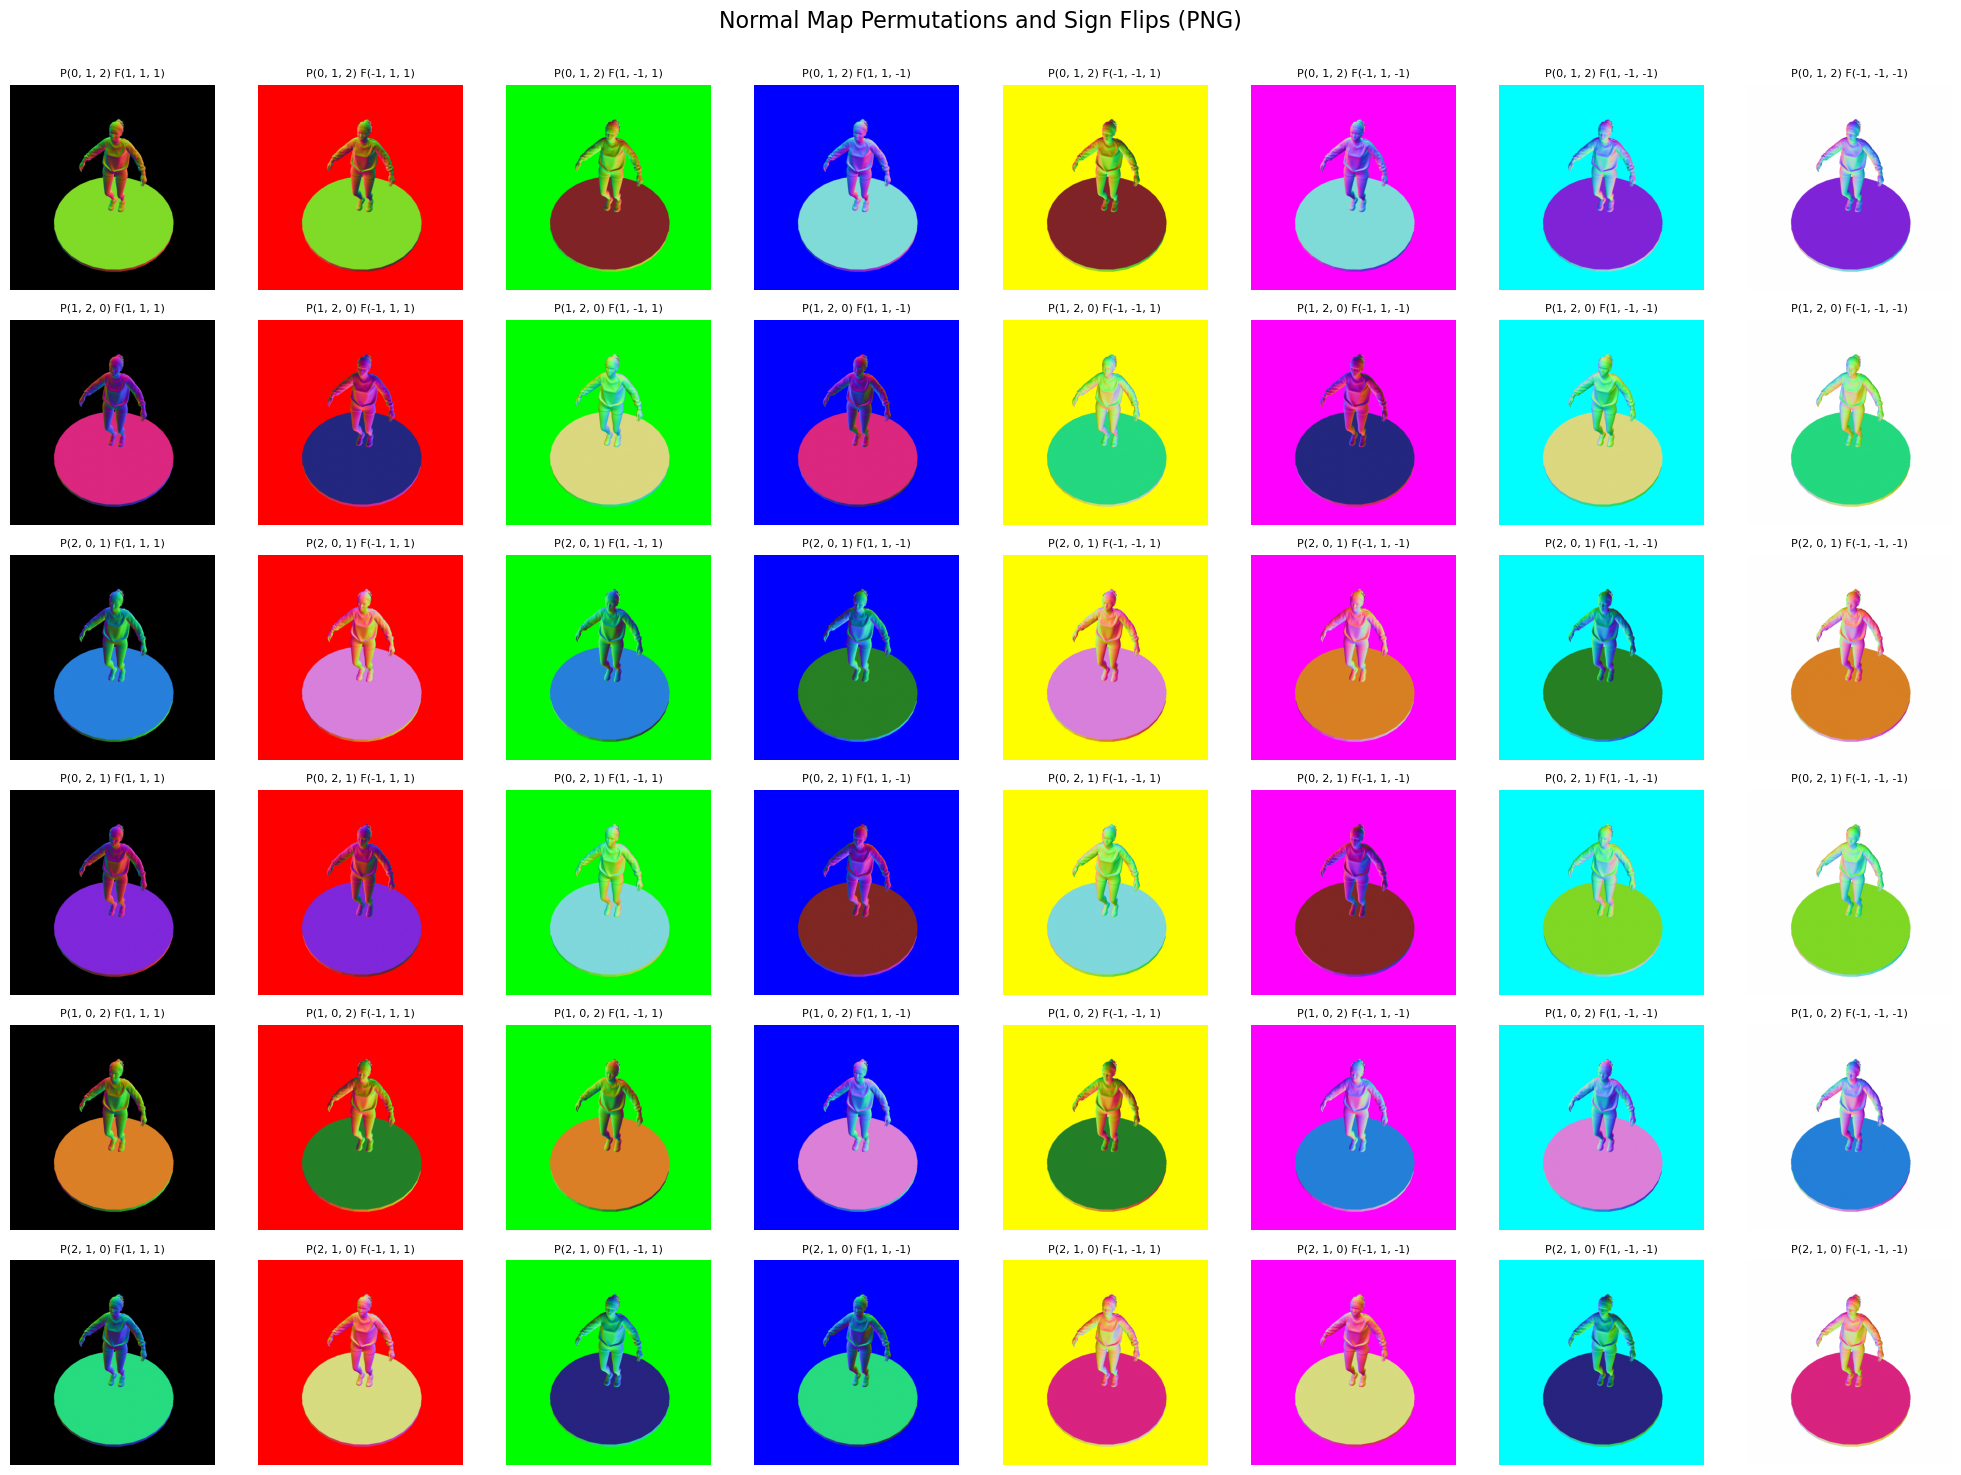

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
import os

# Path to PNG normal map from Blender
image_path = "path/to/normals/rendered/in/blender.png"

if os.path.exists(image_path):
    # Load PNG as float32 normalized to [0, 1]
    img = iio.imread(image_path).astype(np.float32) / 255.0

    # Convert from [0, 1] to [-1, 1] assuming camera-space normals are encoded that way
    normals = img * 2.0 - 1.0  # shape: (H, W, 3)

    # Prepare permutations and sign flips
    permutations = [
        (0, 1, 2), (1, 2, 0), (2, 0, 1),
        (0, 2, 1), (1, 0, 2), (2, 1, 0)
    ]

    sign_flips = [
        (1, 1, 1), (-1, 1, 1), (1, -1, 1), (1, 1, -1),
        (-1, -1, 1), (-1, 1, -1), (1, -1, -1), (-1, -1, -1)
    ]

    # Plot
    fig, axs = plt.subplots(len(permutations), len(sign_flips), figsize=(20, 15))
    fig.suptitle('Normal Map Permutations and Sign Flips (PNG)', fontsize=16)

    for i, perm in enumerate(permutations):
        for j, flip in enumerate(sign_flips):
            transformed = normals[..., list(perm)] * flip#*(-1)
            transformed_vis = (transformed + 1.0) / 2.0  # Rescale to [0, 1] for visualization
            axs[i, j].imshow(transformed_vis.clip(0, 1))
            axs[i, j].axis('off')
            axs[i, j].set_title(f"P{perm} F{flip}", fontsize=8)

    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.show()

else:
    print(f"File not found: {image_path}")
